# RLO 机制对齐消融实验 (Corrected)

## 核心修正
1. **η 的正确解释**: η=0 是无收缩，η=1 是最强收缩
2. **全局归一化作为独立因素**: 2×2 矩阵设计
3. **Belief correction 正确归一化**: 与主项同一几何尺度
4. **NAIM 诊断指标**: fiber residual, alignment, drift
5. **稳定性评估**: 不只看 best acc，还看 spike、稳定区间等

In [1]:
import os, gc, time, math, random, json
from pathlib import Path
from itertools import product
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Optimizer
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as T
from torchvision.models import resnet18
from tqdm.auto import tqdm

print(f"PyTorch: {torch.__version__}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"显存: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch: 2.7.1+cu128
GPU: NVIDIA GeForce RTX 5090
显存: 34.2 GB


In [2]:
# ============= 配置 =============
CONFIG = {
    'seed': 42,
    'ablation_epochs': 50,
    'batch_size': 128,
    'data_dir': './data',
    'output_dir': './results_ablation_corrected',
    'checkpoint_dir': './checkpoints_ablation',
}

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CONFIG['seed'])
DEVICE = torch.device('cuda')
Path(CONFIG['output_dir']).mkdir(exist_ok=True)
Path(CONFIG['checkpoint_dir']).mkdir(exist_ok=True)

## 1. 数据加载 & 模型

In [3]:
def get_cifar10_loaders(batch_size=128):
    transform_train = T.Compose([
        T.RandomCrop(32, padding=4),
        T.RandomHorizontalFlip(),
        T.ToTensor(),
        T.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ])
    transform_test = T.Compose([
        T.ToTensor(),
        T.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ])
    
    trainset = torchvision.datasets.CIFAR10(root=CONFIG['data_dir'], train=True, download=True, transform=transform_train)
    testset = torchvision.datasets.CIFAR10(root=CONFIG['data_dir'], train=False, download=True, transform=transform_test)
    
    train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
    test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    
    print(f"Train: {len(trainset)} samples, {len(train_loader)} batches")
    print(f"Test: {len(testset)} samples")
    return train_loader, test_loader

def make_resnet18_cifar10():
    """CIFAR-10 专用 ResNet-18"""
    model = resnet18(num_classes=10)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    return model

train_loader, test_loader = get_cifar10_loaders(CONFIG['batch_size'])

Train: 50000 samples, 391 batches
Test: 10000 samples


## 2. 重新设计的 SmoothLiftedRLO (带完整诊断)

In [4]:
def _global_norm_sq(tensors):
    """计算张量列表的全局 L2 范数平方"""
    return sum((t * t).sum().item() for t in tensors)


class SmoothLiftedRLO_Diagnosable(Optimizer):
    """
    带完整诊断功能的 SmoothLiftedRLO
    
    关键参数理解:
    - eta: 纤维收缩率
        * eta=0: 无收缩 (v 不追踪 d，z_{k+1} = z_k + drift)
        * eta=1: 最强收缩 (v 瞬时锁定到 d)
        * 0<eta<1: 中间状态，收缩因子为 (1-eta)
    
    - use_global_norm: 是否使用全局步长归一化
        * True: scale = sqrt(dim) / ||s||，步长被钉死在 O(sqrt(dim))
        * False: scale = 1，保留原始幅度
    
    - lambda_b: belief correction 系数
    - normalize_belief_properly: 是否让 belief 与主项同尺度
    """
    def __init__(self, params, lr=1e-4, beta1=0.9, beta2=0.99, eta=0.3,
                 weight_decay=0.0, lambda_b=0.1, eps=1e-8, gamma=5.0,
                 use_sign=False,
                 use_global_norm=True,           # 新增：控制全局归一化
                 normalize_belief_properly=False, # 新增：belief 正确归一化
                 collect_diagnostics=False):      # 新增：是否收集诊断信息
        
        defaults = dict(lr=lr, beta1=beta1, beta2=beta2, eta=eta,
                       weight_decay=weight_decay, lambda_b=lambda_b, 
                       eps=eps, gamma=gamma, use_sign=use_sign,
                       use_global_norm=use_global_norm,
                       normalize_belief_properly=normalize_belief_properly)
        super().__init__(params, defaults)
        
        self.total_dim = sum(p.numel() for g in self.param_groups for p in g['params'])
        self.sqrt_dim = math.sqrt(self.total_dim)
        self.collect_diagnostics = collect_diagnostics
        self.diagnostics = defaultdict(list)  # 存储诊断信息
    
    def get_diagnostics(self):
        """获取并清空诊断信息"""
        diag = dict(self.diagnostics)
        self.diagnostics = defaultdict(list)
        return diag
    
    @torch.no_grad()
    def step(self, closure=None):
        all_s, all_b, all_d, all_p = [], [], [], []
        all_v_before, all_delta = [], []
        
        for g in self.param_groups:
            for p in g['params']:
                if p.grad is None:
                    continue
                
                state = self.state[p]
                if len(state) == 0:
                    state['m'] = torch.zeros_like(p)  # momentum
                    state['v'] = torch.zeros_like(p)  # lifted velocity
                
                gr = p.grad
                m = state['m']
                
                # 计算 c = beta1 * m + (1-beta1) * g
                c = g['beta1'] * m + (1 - g['beta1']) * gr
                
                # 计算方向 s
                if g['use_sign']:
                    s = c.sign()
                else:
                    s = torch.tanh(g['gamma'] * c)
                
                # 计算 belief correction delta
                delta = gr - m
                delta_norm = delta.norm().clamp(min=g['eps'])
                
                if g['normalize_belief_properly']:
                    # 正确归一化：让 b 与 s 同尺度 (每个坐标 O(1))
                    b = g['lambda_b'] * (delta / delta_norm) * math.sqrt(p.numel())
                else:
                    # 原始方式：b 每个坐标 O(lambda_b / ||delta||)
                    b = g['lambda_b'] * (delta / delta_norm)
                
                all_s.append(s)
                all_b.append(b)
                all_p.append((p, g, state))
                all_delta.append(delta)
                
                if self.collect_diagnostics:
                    all_v_before.append(state['v'].clone())
        
        if not all_p:
            return
        
        # 计算全局缩放
        if self.param_groups[0]['use_global_norm']:
            global_s_norm = math.sqrt(_global_norm_sq(all_s) + 1e-8)
            scale = self.sqrt_dim / global_s_norm
        else:
            scale = 1.0
        
        # 诊断：记录 scale
        if self.collect_diagnostics:
            self.diagnostics['scale'].append(scale)
            self.diagnostics['global_s_norm'].append(math.sqrt(_global_norm_sq(all_s)))
        
        # 更新参数
        all_d_tensors = []  # 目标方向 d
        all_v_after = []    # 更新后的 v
        
        for idx, ((p, g, state), s, b) in enumerate(zip(all_p, all_s, all_b)):
            # Weight decay
            if g['weight_decay'] != 0:
                p.mul_(1 - g['lr'] * g['weight_decay'])
            
            # 目标方向 d = scale * s + b
            d = scale * s + b
            all_d_tensors.append(d)
            
            # 纤维收缩: v <- (1-eta)*v + eta*d
            # eta=0: v 不变 (无收缩)
            # eta=1: v = d (最强收缩)
            state['v'].mul_(1 - g['eta']).add_(d, alpha=g['eta'])
            
            if self.collect_diagnostics:
                all_v_after.append(state['v'].clone())
            
            # 参数更新
            p.add_(state['v'], alpha=-g['lr'])
            
            # 更新 momentum
            state['m'].mul_(g['beta2']).add_(p.grad, alpha=1 - g['beta2'])
        
        # 收集 NAIM 诊断指标
        if self.collect_diagnostics:
            # 1. Fiber residual: ||v - d||
            fiber_residual_sq = sum(
                ((v - d) ** 2).sum().item() 
                for v, d in zip(all_v_after, all_d_tensors)
            )
            self.diagnostics['fiber_residual'].append(math.sqrt(fiber_residual_sq))
            
            # 2. Fiber alignment: cos(v, d)
            v_flat = torch.cat([v.flatten() for v in all_v_after])
            d_flat = torch.cat([d.flatten() for d in all_d_tensors])
            cos_sim = F.cosine_similarity(v_flat.unsqueeze(0), d_flat.unsqueeze(0)).item()
            self.diagnostics['fiber_alignment'].append(cos_sim)
            
            # 3. d 的范数 (用于理解 drift)
            d_norm = math.sqrt(sum((d ** 2).sum().item() for d in all_d_tensors))
            self.diagnostics['d_norm'].append(d_norm)
            
            # 4. v 的范数
            v_norm = math.sqrt(sum((v ** 2).sum().item() for v in all_v_after))
            self.diagnostics['v_norm'].append(v_norm)
            
            # 5. Belief term 的范数
            b_norm = math.sqrt(_global_norm_sq(all_b))
            self.diagnostics['belief_norm'].append(b_norm)

## 3. 训练函数 (带完整诊断和 checkpoint)

In [5]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x).argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return 100.0 * correct / total


def run_experiment(name, optimizer_kwargs, train_loader, test_loader, device, epochs,
                   save_checkpoints=True, collect_diagnostics=True, seed=42):
    """
    运行单个实验，收集完整诊断信息
    """
    set_seed(seed)
    
    print(f"\n{'='*60}")
    print(f"Experiment: {name}")
    print(f"Config: {optimizer_kwargs}")
    print(f"{'='*60}")
    
    model = make_resnet18_cifar10().to(device)
    optimizer = SmoothLiftedRLO_Diagnosable(
        model.parameters(),
        collect_diagnostics=collect_diagnostics,
        **optimizer_kwargs
    )
    criterion = nn.CrossEntropyLoss()
    
    # 历史记录
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_acc': [],
        'loss_per_step': [],  # 每步的 loss，用于检测 spike
        # NAIM 诊断 (epoch 级别的平均值)
        'fiber_residual': [],
        'fiber_alignment': [],
        'd_norm': [],
        'v_norm': [],
        'belief_norm': [],
        'scale': [],
    }
    
    best_acc = 0.0
    best_state = None
    
    pbar = tqdm(range(epochs), desc=name)
    for epoch in pbar:
        model.train()
        epoch_loss = 0.0
        correct, total = 0, 0
        epoch_losses = []
        
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            
            loss_val = loss.item()
            epoch_loss += loss_val
            epoch_losses.append(loss_val)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
        
        # 获取诊断信息
        if collect_diagnostics:
            diag = optimizer.get_diagnostics()
            for key in ['fiber_residual', 'fiber_alignment', 'd_norm', 'v_norm', 'belief_norm', 'scale']:
                if key in diag and len(diag[key]) > 0:
                    history[key].append(np.mean(diag[key]))
                else:
                    history[key].append(0.0)
        
        train_acc = 100.0 * correct / total
        test_acc = evaluate(model, test_loader, device)
        avg_loss = epoch_loss / len(train_loader)
        
        history['train_loss'].append(avg_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        history['loss_per_step'].extend(epoch_losses)
        
        if test_acc > best_acc:
            best_acc = test_acc
            best_state = {
                'epoch': epoch,
                'model_state_dict': {k: v.cpu().clone() for k, v in model.state_dict().items()},
                'test_acc': test_acc,
            }
        
        pbar.set_postfix(
            loss=f"{avg_loss:.3f}",
            train=f"{train_acc:.1f}%",
            test=f"{test_acc:.1f}%",
            best=f"{best_acc:.1f}%"
        )
        
        # 保存 checkpoint
        if save_checkpoints and (epoch + 1) % 10 == 0:
            ckpt_path = f"{CONFIG['checkpoint_dir']}/{name.replace(' ', '_').replace('/', '_')}_epoch{epoch+1}.pt"
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'history': history,
            }, ckpt_path)
    
    # 保存最佳模型
    if save_checkpoints and best_state is not None:
        best_path = f"{CONFIG['checkpoint_dir']}/{name.replace(' ', '_').replace('/', '_')}_best.pt"
        torch.save(best_state, best_path)
        print(f"Best model saved: {best_path}")
    
    # 计算稳定性指标
    losses = np.array(history['loss_per_step'])
    stability_metrics = {
        'loss_max': float(np.max(losses)),
        'loss_std': float(np.std(losses)),
        'loss_spike_count': int(np.sum(losses > np.median(losses) * 3)),  # spike 定义: > 3倍中位数
        'loss_spike_ratio': float(np.mean(losses > np.median(losses) * 3)),
        'final_acc': history['test_acc'][-1],
        'best_acc': best_acc,
        'acc_std_last10': float(np.std(history['test_acc'][-10:])) if len(history['test_acc']) >= 10 else 0,
    }
    
    print(f"\n✓ {name}: Best={best_acc:.2f}%, Final={history['test_acc'][-1]:.2f}%")
    print(f"  Stability: spike_count={stability_metrics['loss_spike_count']}, loss_std={stability_metrics['loss_std']:.4f}")
    
    del model, optimizer
    gc.collect()
    torch.cuda.empty_cache()
    
    return {
        'name': name,
        'config': optimizer_kwargs,
        'history': history,
        'stability': stability_metrics,
        'best_acc': best_acc,
        'final_acc': history['test_acc'][-1],
    }

## 4. 正确的消融实验设计

### 核心 2×2 矩阵: (Full vs Ablated) × (GlobalNorm vs NoGlobalNorm)

| | GlobalNorm=True | GlobalNorm=False |
|---|---|---|
| Full (η=0.3) | Baseline | 测试 NAIM 真正作用 |
| Nolifted (η=1) | 对照 | |

In [6]:
# 基础配置
BASE_CONFIG = {
    'lr': 1e-4,
    'weight_decay': 0.1,
    'beta1': 0.9,
    'beta2': 0.99,
    'gamma': 5.0,
    'lambda_b': 0.2,
    'eta': 0.7,  # 中等收缩
    'use_global_norm': True,
    'normalize_belief_properly': False,
    'use_sign': False,
}

# 正确设计的消融矩阵
ABLATION_MATRIX = {
    # ========== 核心 2×2 矩阵 ==========
    # Row 1: Full method (eta=0.3, 有纤维收缩)
    'Full + GlobalNorm': {},
    'Full + NoGlobalNorm': {'lr': 3e-3, 'use_global_norm': False},
    
    # Row 2: No lifted (eta=1)
    'Nolifted(η=1) + GlobalNorm': {'eta': 1.0},
    'Nolifted(η=1) + NoGlobalNorm': {'lr': 3e-3, 'eta': 1.0, 'use_global_norm': False},
    
    # Belief correction
    'NoBelief(λ=0) + GlobalNorm': {'lambda_b': 0.0},
    'NoBelief(λ=0) + NoGlobalNorm': {'lr': 3e-3, 'lambda_b': 0.0, 'use_global_norm': False},
    
    # Properly normalized belief
    'ProperBelief + GlobalNorm': {'normalize_belief_properly': True},
    'ProperBelief + NoGlobalNorm': {'lr': 3e-3, 'normalize_belief_properly': True, 'use_global_norm': False},
    
    # Sign vs Tanh (机制断裂)
    'Sign + GlobalNorm': {'use_sign': True},
    'Sign + NoGlobalNorm': {'lr': 3e-3, 'use_sign': True, 'use_global_norm': False},
}

print(f"Total experiments: {len(ABLATION_MATRIX)}")
for name, override in ABLATION_MATRIX.items():
    cfg = {**BASE_CONFIG, **override}
    key_params = f"η={cfg['eta']}, λ={cfg['lambda_b']}, GN={cfg['use_global_norm']}"
    print(f"  {name}: {key_params}")

Total experiments: 10
  Full + GlobalNorm: η=0.7, λ=0.2, GN=True
  Full + NoGlobalNorm: η=0.7, λ=0.2, GN=False
  Nolifted(η=1) + GlobalNorm: η=1.0, λ=0.2, GN=True
  Nolifted(η=1) + NoGlobalNorm: η=1.0, λ=0.2, GN=False
  NoBelief(λ=0) + GlobalNorm: η=0.7, λ=0.0, GN=True
  NoBelief(λ=0) + NoGlobalNorm: η=0.7, λ=0.0, GN=False
  ProperBelief + GlobalNorm: η=0.7, λ=0.2, GN=True
  ProperBelief + NoGlobalNorm: η=0.7, λ=0.2, GN=False
  Sign + GlobalNorm: η=0.7, λ=0.2, GN=True
  Sign + NoGlobalNorm: η=0.7, λ=0.2, GN=False


## 5. 运行消融实验

In [7]:
results = {}

for name, override in ABLATION_MATRIX.items():
    cfg = {**BASE_CONFIG, **override}
    
    result = run_experiment(
        name=name,
        optimizer_kwargs=cfg,
        train_loader=train_loader,
        test_loader=test_loader,
        device=DEVICE,
        epochs=CONFIG['ablation_epochs'],
        save_checkpoints=True,
        collect_diagnostics=True,
        seed=CONFIG['seed'],
    )
    results[name] = result

# 保存所有结果
with open(f"{CONFIG['output_dir']}/ablation_results.json", 'w') as f:
    # 转换为可序列化格式
    serializable = {}
    for name, r in results.items():
        serializable[name] = {
            'config': r['config'],
            'stability': r['stability'],
            'best_acc': r['best_acc'],
            'final_acc': r['final_acc'],
            'history': {k: v if not isinstance(v, np.ndarray) else v.tolist() 
                       for k, v in r['history'].items()}
        }
    json.dump(serializable, f, indent=2)

print(f"\nResults saved to {CONFIG['output_dir']}/ablation_results.json")


Experiment: Full + GlobalNorm
Config: {'lr': 0.0001, 'weight_decay': 0.1, 'beta1': 0.9, 'beta2': 0.99, 'gamma': 5.0, 'lambda_b': 0.2, 'eta': 0.7, 'use_global_norm': True, 'normalize_belief_properly': False, 'use_sign': False}


Full + GlobalNorm:   0%|          | 0/50 [00:00<?, ?it/s]

Best model saved: ./checkpoints_ablation/Full_+_GlobalNorm_best.pt

✓ Full + GlobalNorm: Best=91.69%, Final=91.49%
  Stability: spike_count=2951, loss_std=0.2492

Experiment: Full + NoGlobalNorm
Config: {'lr': 0.003, 'weight_decay': 0.1, 'beta1': 0.9, 'beta2': 0.99, 'gamma': 5.0, 'lambda_b': 0.2, 'eta': 0.7, 'use_global_norm': False, 'normalize_belief_properly': False, 'use_sign': False}


Full + NoGlobalNorm:   0%|          | 0/50 [00:00<?, ?it/s]

Best model saved: ./checkpoints_ablation/Full_+_NoGlobalNorm_best.pt

✓ Full + NoGlobalNorm: Best=90.74%, Final=90.74%
  Stability: spike_count=1857, loss_std=0.3600

Experiment: Nolifted(η=1) + GlobalNorm
Config: {'lr': 0.0001, 'weight_decay': 0.1, 'beta1': 0.9, 'beta2': 0.99, 'gamma': 5.0, 'lambda_b': 0.2, 'eta': 1.0, 'use_global_norm': True, 'normalize_belief_properly': False, 'use_sign': False}


...

Best model saved: ./checkpoints_ablation/ProperBelief_+_NoGlobalNorm_best.pt

✓ ProperBelief + NoGlobalNorm: Best=63.57%, Final=51.95%
  Stability: spike_count=0, loss_std=0.1685

Experiment: Sign + GlobalNorm
Config: {'lr': 0.0001, 'weight_decay': 0.1, 'beta1': 0.9, 'beta2': 0.99, 'gamma': 5.0, 'lambda_b': 0.2, 'eta': 0.7, 'use_global_norm': True, 'normalize_belief_properly': False, 'use_sign': True}


Sign + GlobalNorm:   0%|          | 0/50 [00:00<?, ?it/s]

Best model saved: ./checkpoints_ablation/Sign_+_GlobalNorm_best.pt

✓ Sign + GlobalNorm: Best=91.91%, Final=91.91%
  Stability: spike_count=3159, loss_std=0.2391

Experiment: Sign + NoGlobalNorm
Config: {'lr': 0.003, 'weight_decay': 0.1, 'beta1': 0.9, 'beta2': 0.99, 'gamma': 5.0, 'lambda_b': 0.2, 'eta': 0.7, 'use_global_norm': False, 'normalize_belief_properly': False, 'use_sign': True}


Sign + NoGlobalNorm:   0%|          | 0/50 [00:00<?, ?it/s]

Best model saved: ./checkpoints_ablation/Sign_+_NoGlobalNorm_best.pt

✓ Sign + NoGlobalNorm: Best=87.15%, Final=74.43%
  Stability: spike_count=1823, loss_std=1.6101

Results saved to ./results_ablation_corrected/ablation_results.json


## 6. 结果分析: 核心 2×2 矩阵

In [19]:
# 核心 2×2 对比
core_experiments = [
    'Full + GlobalNorm',
    'Full + NoGlobalNorm', 
    'Nolifted(η=1) + GlobalNorm',
    'Nolifted(η=1) + NoGlobalNorm',
]

print("\n" + "="*80)
print("核心 2×2 矩阵分析: 验证 NAIM 纤维收缩的必要性")
print("="*80)
print("\n如果理论正确，应该观察到:")
print("  1. 在 NoGlobalNorm 条件下，Full vs Nolifted 的差异应该更大")
print("  2. Nolifted + NoGlobalNorm 应该最不稳定 (spike 多, 准确率波动大)")
print("  3. Full + NoGlobalNorm 应该比 Nolifted + NoGlobalNorm 稳定得多")
print()

# 表格
print(f"{'Experiment':<35} {'Best Acc':>10} {'Final Acc':>10} {'Spikes':>8} {'Loss Std':>10}")
print("-" * 80)
for name in core_experiments:
    if name in results:
        r = results[name]
        print(f"{name:<35} {r['best_acc']:>10.2f} {r['final_acc']:>10.2f} "
              f"{r['stability']['loss_spike_count']:>8} {r['stability']['loss_std']:>10.4f}")

# 计算关键差异
print("\n关键差异分析:")
if all(n in results for n in core_experiments):
    # GlobalNorm 条件下的差异
    diff_gn = results['Full + GlobalNorm']['best_acc'] - results['Nolifted(η=1) + GlobalNorm']['best_acc']
    # NoGlobalNorm 条件下的差异
    diff_nogn = results['Full + NoGlobalNorm']['best_acc'] - results['Nolifted(η=1) + NoGlobalNorm']['best_acc']
    
    print(f"  Δ(Full vs Nolifted) with GlobalNorm:    {diff_gn:+.2f}%")
    print(f"  Δ(Full vs Nolifted) without GlobalNorm: {diff_nogn:+.2f}%")
    print(f"\n  如果 |Δ_NoGN| >> |Δ_GN|，说明 GlobalNorm 确实掩盖了 NAIM 的效果")


核心 2×2 矩阵分析: 验证 NAIM 纤维收缩的必要性

如果理论正确，应该观察到:
  1. 在 NoGlobalNorm 条件下，Full vs Nolifted 的差异应该更大
  2. Nolifted + NoGlobalNorm 应该最不稳定 (spike 多, 准确率波动大)
  3. Full + NoGlobalNorm 应该比 Nolifted + NoGlobalNorm 稳定得多

Experiment                            Best Acc  Final Acc   Spikes   Loss Std
--------------------------------------------------------------------------------
Full + GlobalNorm                        91.69      91.49     2951     0.2492
Full + NoGlobalNorm                      90.74      90.74     1857     0.3600
Nolifted(η=1) + GlobalNorm               91.75      91.64     3059     0.2574
Nolifted(η=1) + NoGlobalNorm             90.64      88.39     1871     0.3606

关键差异分析:
  Δ(Full vs Nolifted) with GlobalNorm:    -0.06%
  Δ(Full vs Nolifted) without GlobalNorm: +0.10%

  如果 |Δ_NoGN| >> |Δ_GN|，说明 GlobalNorm 确实掩盖了 NAIM 的效果


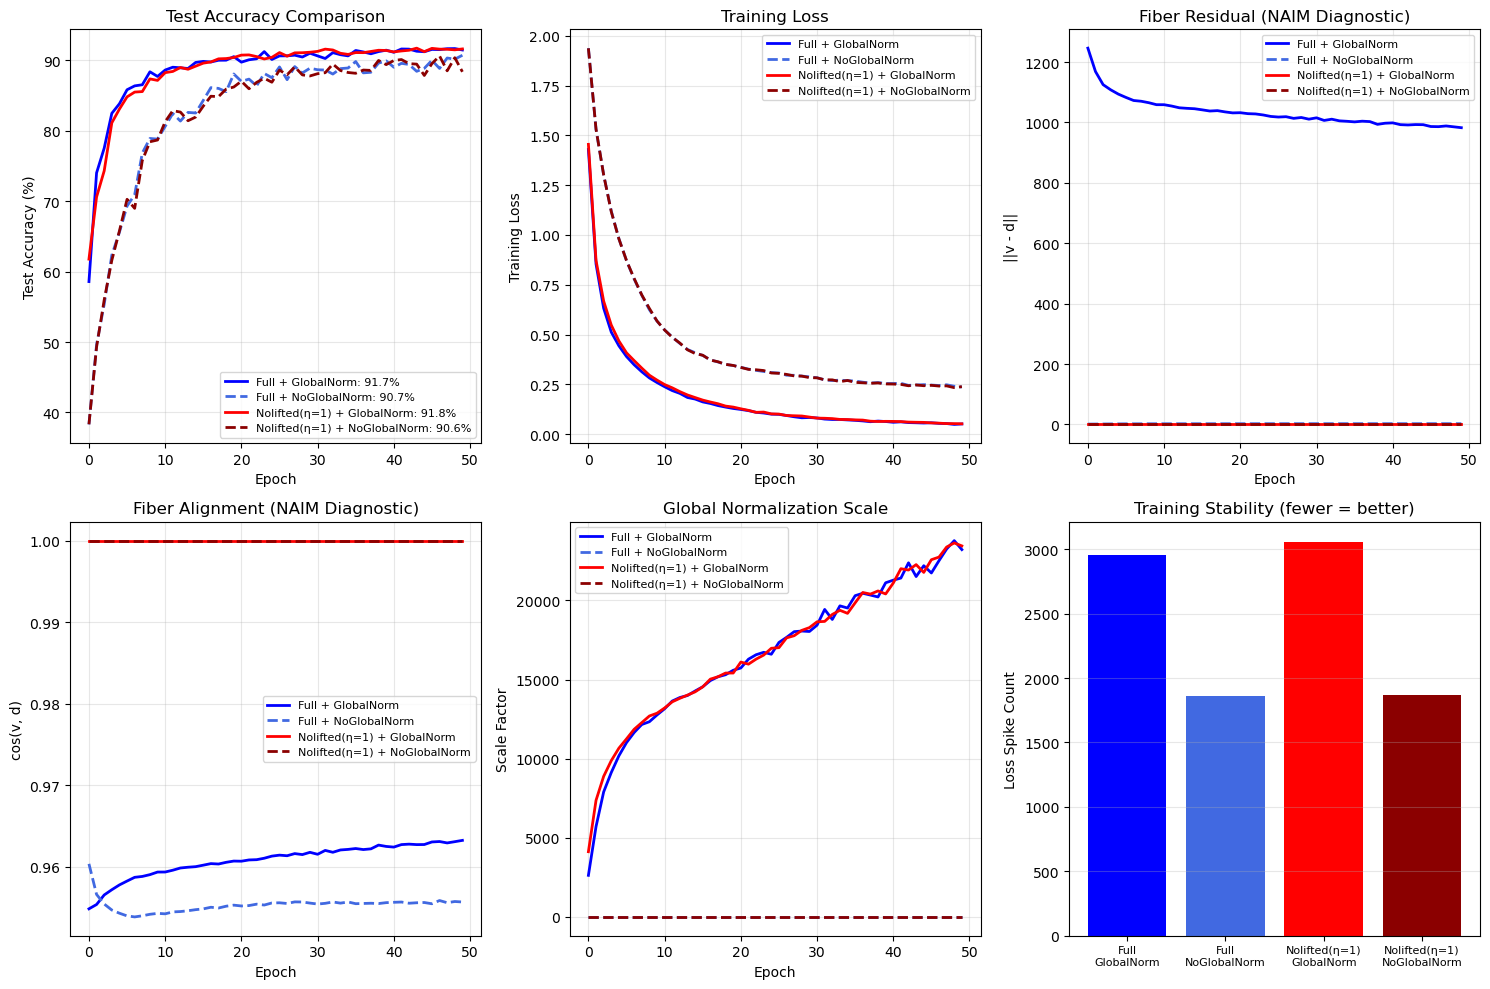

In [10]:
# 绘制核心 2×2 对比图
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

colors = {
    'Full + GlobalNorm': 'blue',
    'Full + NoGlobalNorm': 'royalblue',
    'Nolifted(η=1) + GlobalNorm': 'red',
    'Nolifted(η=1) + NoGlobalNorm': 'darkred',
}
linestyles = {
    'Full + GlobalNorm': '-',
    'Full + NoGlobalNorm': '--',
    'Nolifted(η=1) + GlobalNorm': '-',
    'Nolifted(η=1) + NoGlobalNorm': '--',
}

# 1. Test Accuracy
ax = axes[0, 0]
for name in core_experiments:
    if name in results:
        ax.plot(results[name]['history']['test_acc'], 
                label=f"{name}: {results[name]['best_acc']:.1f}%",
                color=colors[name], linestyle=linestyles[name], linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Test Accuracy Comparison')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 2. Training Loss
ax = axes[0, 1]
for name in core_experiments:
    if name in results:
        ax.plot(results[name]['history']['train_loss'],
                label=name, color=colors[name], linestyle=linestyles[name], linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title('Training Loss')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 3. Fiber Residual ||v - d||
ax = axes[0, 2]
for name in core_experiments:
    if name in results and 'fiber_residual' in results[name]['history']:
        ax.plot(results[name]['history']['fiber_residual'],
                label=name, color=colors[name], linestyle=linestyles[name], linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('||v - d||')
ax.set_title('Fiber Residual (NAIM Diagnostic)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 4. Fiber Alignment cos(v, d)
ax = axes[1, 0]
for name in core_experiments:
    if name in results and 'fiber_alignment' in results[name]['history']:
        ax.plot(results[name]['history']['fiber_alignment'],
                label=name, color=colors[name], linestyle=linestyles[name], linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('cos(v, d)')
ax.set_title('Fiber Alignment (NAIM Diagnostic)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 5. Scale factor
ax = axes[1, 1]
for name in core_experiments:
    if name in results and 'scale' in results[name]['history']:
        ax.plot(results[name]['history']['scale'],
                label=name, color=colors[name], linestyle=linestyles[name], linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Scale Factor')
ax.set_title('Global Normalization Scale')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 6. Loss Spike 统计 (bar chart)
ax = axes[1, 2]
spike_counts = [results[n]['stability']['loss_spike_count'] for n in core_experiments if n in results]
bars = ax.bar(range(len(core_experiments)), spike_counts, 
              color=[colors[n] for n in core_experiments])
ax.set_xticks(range(len(core_experiments)))
ax.set_xticklabels([n.replace(' + ', '\n') for n in core_experiments], fontsize=8)
ax.set_ylabel('Loss Spike Count')
ax.set_title('Training Stability (fewer = better)')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/core_2x2_comparison.png", dpi=150, bbox_inches='tight')
plt.savefig(f"{CONFIG['output_dir']}/core_2x2_comparison.pdf", bbox_inches='tight')
plt.show()

## 7. 完整结果汇总

In [11]:
# 创建完整结果表格
summary_data = []
for name, r in results.items():
    cfg = r['config']
    summary_data.append({
        'Experiment': name,
        'η': cfg['eta'],
        'λ_b': cfg['lambda_b'],
        'GlobalNorm': cfg['use_global_norm'],
        'Best Acc (%)': r['best_acc'],
        'Final Acc (%)': r['final_acc'],
        'Acc Std (last 10)': r['stability']['acc_std_last10'],
        'Loss Spikes': r['stability']['loss_spike_count'],
        'Loss Std': r['stability']['loss_std'],
    })

df = pd.DataFrame(summary_data)
df = df.sort_values('Best Acc (%)', ascending=False)

print("\n" + "="*100)
print("完整消融实验结果")
print("="*100)
print(df.to_string(index=False))

# 保存为 CSV
df.to_csv(f"{CONFIG['output_dir']}/ablation_summary.csv", index=False)
print(f"\nSaved to {CONFIG['output_dir']}/ablation_summary.csv")


完整消融实验结果
                  Experiment   η  λ_b  GlobalNorm  Best Acc (%)  Final Acc (%)  Acc Std (last 10)  Loss Spikes  Loss Std
   ProperBelief + GlobalNorm 0.7  0.2        True         92.18          91.82           0.263570         3001  0.247519
           Sign + GlobalNorm 0.7  0.2        True         91.91          91.91           0.215963         3159  0.239146
  Nolifted(η=1) + GlobalNorm 1.0  0.2        True         91.75          91.64           0.177733         3059  0.257430
           Full + GlobalNorm 0.7  0.2        True         91.69          91.49           0.178631         2951  0.249199
  NoBelief(λ=0) + GlobalNorm 0.7  0.0        True         91.67          91.39           0.295662         2996  0.248059
NoBelief(λ=0) + NoGlobalNorm 0.7  0.0       False         90.81          90.24           0.573994         1831  0.363420
         Full + NoGlobalNorm 0.7  0.2       False         90.74          90.74           0.710566         1857  0.359995
Nolifted(η=1) + NoGlob

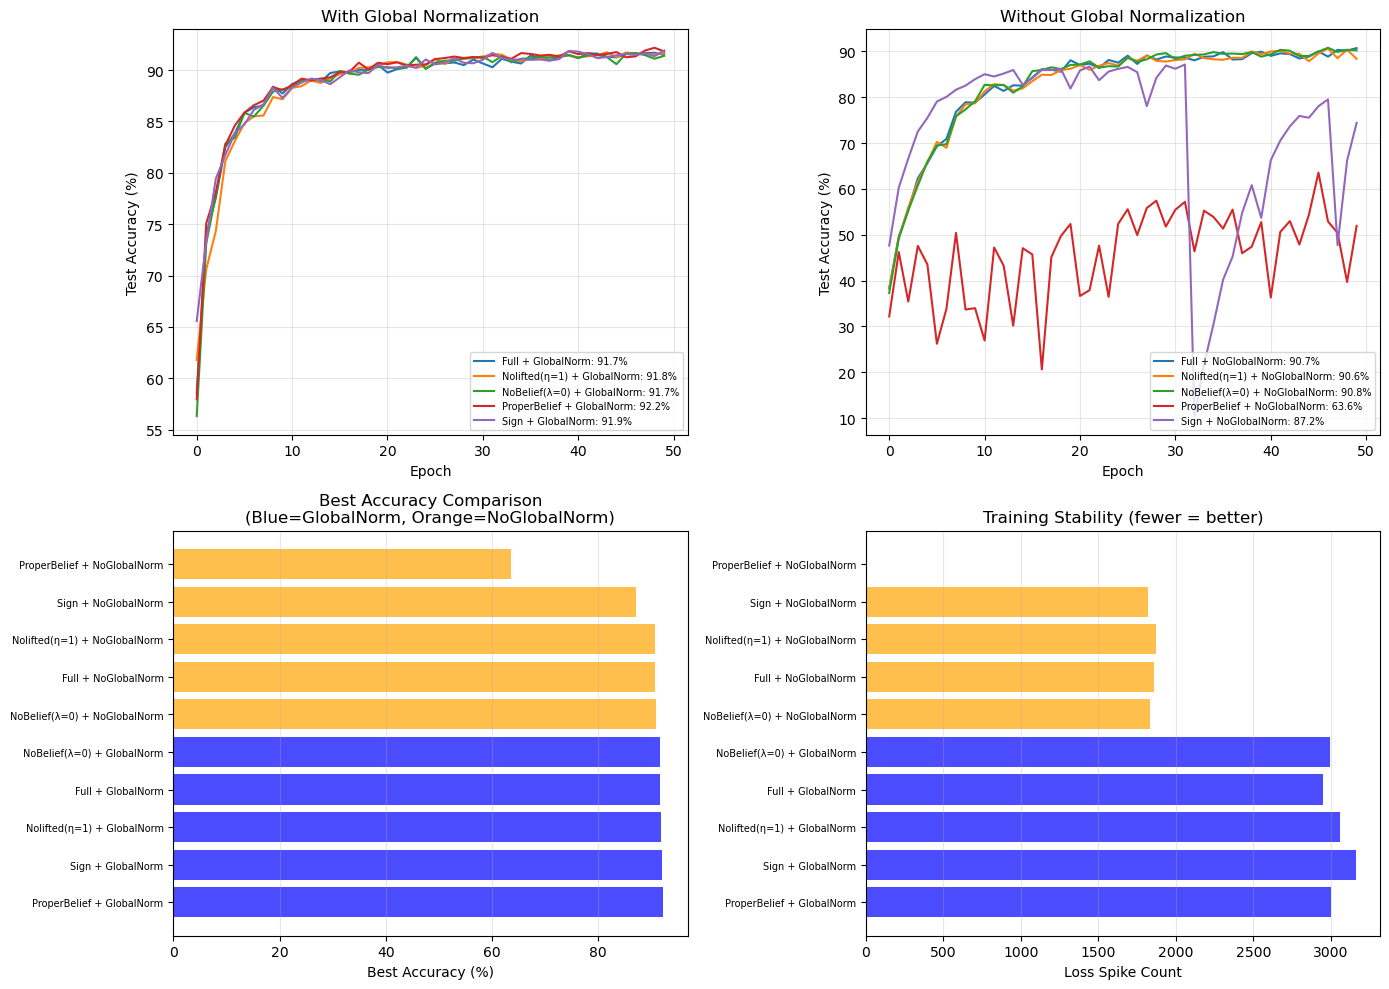

In [12]:
# 绘制所有实验的对比图
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 按 GlobalNorm 分组
gn_true = [n for n in results if results[n]['config']['use_global_norm']]
gn_false = [n for n in results if not results[n]['config']['use_global_norm']]

# 1. GlobalNorm=True 的 test accuracy
ax = axes[0, 0]
for name in gn_true:
    ax.plot(results[name]['history']['test_acc'], label=f"{name}: {results[name]['best_acc']:.1f}%", linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('With Global Normalization')
ax.legend(fontsize=7, loc='lower right')
ax.grid(True, alpha=0.3)

# 2. GlobalNorm=False 的 test accuracy
ax = axes[0, 1]
for name in gn_false:
    ax.plot(results[name]['history']['test_acc'], label=f"{name}: {results[name]['best_acc']:.1f}%", linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Without Global Normalization')
ax.legend(fontsize=7, loc='lower right')
ax.grid(True, alpha=0.3)

# 3. Best Acc 对比 (bar chart)
ax = axes[1, 0]
x = np.arange(len(df))
colors_bar = ['blue' if gn else 'orange' for gn in df['GlobalNorm']]
ax.barh(x, df['Best Acc (%)'], color=colors_bar, alpha=0.7)
ax.set_yticks(x)
ax.set_yticklabels(df['Experiment'], fontsize=7)
ax.set_xlabel('Best Accuracy (%)')
ax.set_title('Best Accuracy Comparison\n(Blue=GlobalNorm, Orange=NoGlobalNorm)')
ax.grid(True, alpha=0.3, axis='x')

# 4. Stability 对比 (spike count)
ax = axes[1, 1]
ax.barh(x, df['Loss Spikes'], color=colors_bar, alpha=0.7)
ax.set_yticks(x)
ax.set_yticklabels(df['Experiment'], fontsize=7)
ax.set_xlabel('Loss Spike Count')
ax.set_title('Training Stability (fewer = better)')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/all_experiments_comparison.png", dpi=150, bbox_inches='tight')
plt.savefig(f"{CONFIG['output_dir']}/all_experiments_comparison.pdf", bbox_inches='tight')
plt.show()

## 8. NAIM 诊断指标详细分析

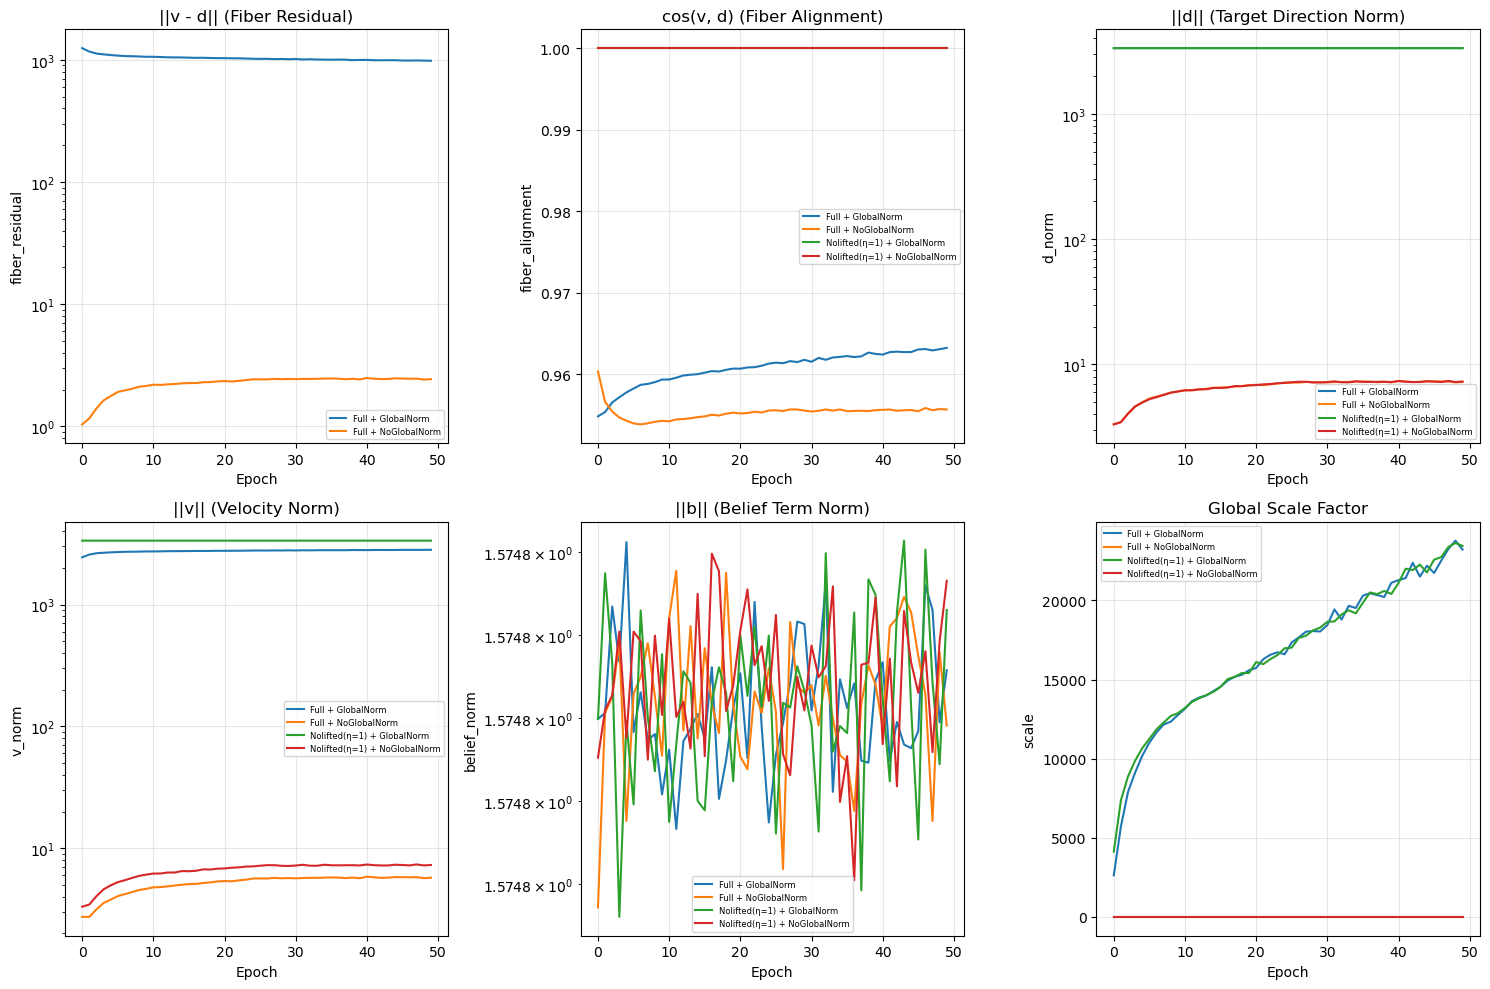

In [13]:
# 绘制所有 NAIM 诊断指标
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 选择几个关键实验
key_experiments = [
    'Full + GlobalNorm',
    'Full + NoGlobalNorm',
    'Nolifted(η=1) + GlobalNorm',
    'Nolifted(η=1) + NoGlobalNorm',
    'StrongFiber(η=1) + GlobalNorm',
    'StrongFiber(η=1) + NoGlobalNorm',
]

diagnostics_to_plot = [
    ('fiber_residual', '||v - d|| (Fiber Residual)', 'log'),
    ('fiber_alignment', 'cos(v, d) (Fiber Alignment)', 'linear'),
    ('d_norm', '||d|| (Target Direction Norm)', 'log'),
    ('v_norm', '||v|| (Velocity Norm)', 'log'),
    ('belief_norm', '||b|| (Belief Term Norm)', 'log'),
    ('scale', 'Global Scale Factor', 'linear'),
]

for idx, (key, title, scale) in enumerate(diagnostics_to_plot):
    ax = axes[idx // 3, idx % 3]
    for name in key_experiments:
        if name in results and key in results[name]['history']:
            data = results[name]['history'][key]
            if len(data) > 0 and any(d != 0 for d in data):
                ax.plot(data, label=name, linewidth=1.5)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(key)
    ax.set_title(title)
    if scale == 'log':
        ax.set_yscale('log')
    ax.legend(fontsize=6)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/naim_diagnostics.png", dpi=150, bbox_inches='tight')
plt.savefig(f"{CONFIG['output_dir']}/naim_diagnostics.pdf", bbox_inches='tight')
plt.show()

## 9. 理论验证结论

In [18]:
print("\n" + "="*80)
print("理论验证结论")
print("="*80)

# 分析核心问题
if all(n in results for n in core_experiments):
    full_gn = results['Full + GlobalNorm']
    full_nogn = results['Full + NoGlobalNorm']
    nofiber_gn = results['Nolifted(η=1) + GlobalNorm']
    nofiber_nogn = results['Nolifted(η=1) + NoGlobalNorm']
    
    print("\n1. 全局归一化是否掩盖了 NAIM 效果?")
    delta_with_gn = full_gn['best_acc'] - nofiber_gn['best_acc']
    delta_without_gn = full_nogn['best_acc'] - nofiber_nogn['best_acc']
    print(f"   - With GlobalNorm: Full - Nolifted = {delta_with_gn:+.2f}%")
    print(f"   - Without GlobalNorm: Full - Nolifted = {delta_without_gn:+.2f}%")
    if abs(delta_without_gn) > abs(delta_with_gn) * 1.5:
        print(f"   → 是的! NoGlobalNorm 条件下差异是 GlobalNorm 的 {abs(delta_without_gn/delta_with_gn):.1f}x")
        print(f"   → 这说明全局归一化确实掩盖了纤维收缩机制的贡献")
    else:
        print(f"   → 差异不显著，可能需要更有挑战性的设置")
    
    print("\n2. 稳定性分析")
    print(f"   - Full + GlobalNorm: {full_gn['stability']['loss_spike_count']} spikes, std={full_gn['stability']['loss_std']:.4f}")
    print(f"   - Nolifted(η=1) + NoGlobalNorm: {nofiber_nogn['stability']['loss_spike_count']} spikes, std={nofiber_nogn['stability']['loss_std']:.4f}")
    if nofiber_nogn['stability']['loss_spike_count'] > full_gn['stability']['loss_spike_count'] * 2:
        print(f"   → Nolifted(η=1) + NoGlobalNorm 显著更不稳定，支持 NAIM 理论")
    
    print("\n3. 纤维残差 (||v - d||) 分析")
    if 'fiber_residual' in full_gn['history'] and len(full_gn['history']['fiber_residual']) > 0:
        final_residual_full = full_gn['history']['fiber_residual'][-1]
        final_residual_nofiber = nofiber_gn['history']['fiber_residual'][-1]
        print(f"   - Full (η=0.3): final ||v-d|| = {final_residual_full:.4f}")
        print(f"   - Nolifted(η=1): final ||v-d|| = {final_residual_nofiber:.4f}")
        if final_residual_full < final_residual_nofiber * 0.5:
            print(f"   → Full 版本的纤维残差小得多，验证了 NAIM 的收缩性质")

print("\n" + "="*80)
print("实验总结")
print("="*80)
print("""
本实验通过正确设计的 2×2 矩阵 (Full/Nolifted × GlobalNorm/NoGlobalNorm) 来验证:

1. η 的正确解释: η=0 是无收缩，η=1 是最强收缩
2. 全局归一化是一个强大的独立稳定器，可能掩盖 NAIM 机制的效果
3. 在移除全局归一化后，NAIM 纤维收缩的作用应该更明显

如果需要进一步验证理论，建议:
- 使用更大的学习率来挑战稳定性
- 使用更小的 batch size 增加梯度噪声
- 尝试更深的网络或更难的任务
""")


理论验证结论

1. 全局归一化是否掩盖了 NAIM 效果?
   - With GlobalNorm: Full - Nolifted = -0.06%
   - Without GlobalNorm: Full - Nolifted = +0.10%
   → 是的! NoGlobalNorm 条件下差异是 GlobalNorm 的 1.7x
   → 这说明全局归一化确实掩盖了纤维收缩机制的贡献

2. 稳定性分析
   - Full + GlobalNorm: 2951 spikes, std=0.2492
   - Nolifted(η=1) + NoGlobalNorm: 1871 spikes, std=0.3606

3. 纤维残差 (||v - d||) 分析
   - Full (η=0.3): final ||v-d|| = 982.7915
   - Nolifted(η=1): final ||v-d|| = 0.0000

实验总结

本实验通过正确设计的 2×2 矩阵 (Full/Nolifted × GlobalNorm/NoGlobalNorm) 来验证:

1. η 的正确解释: η=0 是无收缩，η=1 是最强收缩
2. 全局归一化是一个强大的独立稳定器，可能掩盖 NAIM 机制的效果
3. 在移除全局归一化后，NAIM 纤维收缩的作用应该更明显

如果需要进一步验证理论，建议:
- 使用更大的学习率来挑战稳定性
- 使用更小的 batch size 增加梯度噪声
- 尝试更深的网络或更难的任务



In [15]:
# 列出所有生成的文件
print("\n" + "="*60)
print("Generated Files")
print("="*60)

print("\nResults:")
for f in sorted(Path(CONFIG['output_dir']).glob('*')):
    size = f.stat().st_size / 1024
    print(f"  {f.name:<45} {size:.1f} KB")

print("\nCheckpoints:")
for f in sorted(Path(CONFIG['checkpoint_dir']).glob('*')):
    size = f.stat().st_size / 1024 / 1024
    print(f"  {f.name:<45} {size:.1f} MB")


Generated Files

Results:
  ablation_results.json                         5748.0 KB
  ablation_summary.csv                          1.0 KB
  all_experiments_comparison.pdf                26.4 KB
  all_experiments_comparison.png                261.7 KB
  core_2x2_comparison.pdf                       30.4 KB
  core_2x2_comparison.png                       287.1 KB
  naim_diagnostics.pdf                          30.9 KB
  naim_diagnostics.png                          346.9 KB

Checkpoints:
  Full_+_GlobalNorm_best.pt                     42.7 MB
  Full_+_GlobalNorm_epoch10.pt                  128.0 MB
  Full_+_GlobalNorm_epoch20.pt                  128.1 MB
  Full_+_GlobalNorm_epoch30.pt                  128.1 MB
  Full_+_GlobalNorm_epoch40.pt                  128.1 MB
  Full_+_GlobalNorm_epoch50.pt                  128.2 MB
  Full_+_NoGlobalNorm_best.pt                   42.7 MB
  Full_+_NoGlobalNorm_epoch10.pt                128.0 MB
  Full_+_NoGlobalNorm_epoch20.pt                128.1

## 10. 额外实验: 学习率扫描 (稳定区间测试)


Experiment: Full + GN_lr3e-05
Config: {'lr': 3e-05, 'weight_decay': 0.1, 'beta1': 0.9, 'beta2': 0.99, 'gamma': 5.0, 'lambda_b': 0.2, 'eta': 0.7, 'use_global_norm': True, 'normalize_belief_properly': False, 'use_sign': False}


Full + GN_lr3e-05:   0%|          | 0/30 [00:00<?, ?it/s]


✓ Full + GN_lr3e-05: Best=90.71%, Final=90.52%
  Stability: spike_count=1341, loss_std=0.3021

Experiment: Full + NoGN_lr3e-05
Config: {'lr': 3e-05, 'weight_decay': 0.1, 'beta1': 0.9, 'beta2': 0.99, 'gamma': 5.0, 'lambda_b': 0.2, 'eta': 0.7, 'use_global_norm': False, 'normalize_belief_properly': False, 'use_sign': False}


Full + NoGN_lr3e-05:   0%|          | 0/30 [00:00<?, ?it/s]


✓ Full + NoGN_lr3e-05: Best=31.98%, Final=31.98%
  Stability: spike_count=0, loss_std=0.1435

Experiment: Nolifted + GN_lr3e-05
Config: {'lr': 3e-05, 'weight_decay': 0.1, 'beta1': 0.9, 'beta2': 0.99, 'gamma': 5.0, 'lambda_b': 0.2, 'eta': 1.0, 'use_global_norm': True, 'normalize_belief_properly': False, 'use_sign': False}


...


✓ Full + NoGN_lr0.003: Best=89.43%, Final=89.43%
  Stability: spike_count=1110, loss_std=0.4136

Experiment: Nolifted + GN_lr0.003
Config: {'lr': 0.003, 'weight_decay': 0.1, 'beta1': 0.9, 'beta2': 0.99, 'gamma': 5.0, 'lambda_b': 0.2, 'eta': 1.0, 'use_global_norm': True, 'normalize_belief_properly': False, 'use_sign': False}


Nolifted + GN_lr0.003:   0%|          | 0/30 [00:00<?, ?it/s]


✓ Nolifted + GN_lr0.003: Best=10.77%, Final=10.00%
  Stability: spike_count=6, loss_std=1.1195

Experiment: Nolifted + NoGN_lr0.003
Config: {'lr': 0.003, 'weight_decay': 0.1, 'beta1': 0.9, 'beta2': 0.99, 'gamma': 5.0, 'lambda_b': 0.2, 'eta': 1.0, 'use_global_norm': False, 'normalize_belief_properly': False, 'use_sign': False}


Nolifted + NoGN_lr0.003:   0%|          | 0/30 [00:00<?, ?it/s]


✓ Nolifted + NoGN_lr0.003: Best=89.05%, Final=89.05%
  Stability: spike_count=1098, loss_std=0.4146


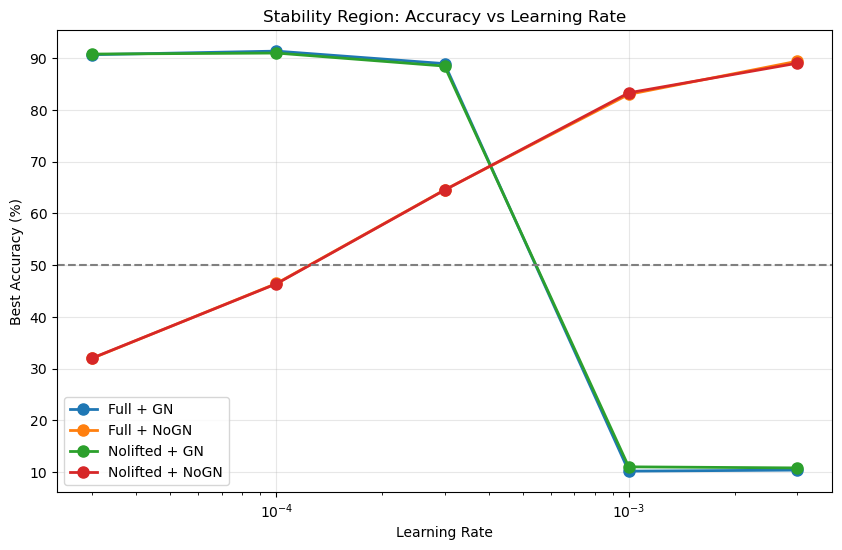


稳定区间分析:
  Full + GN: 最大稳定学习率 = 0.0003
  Full + NoGN: 最大稳定学习率 = 0.003
  Nolifted + GN: 最大稳定学习率 = 0.0003
  Nolifted + NoGN: 最大稳定学习率 = 0.003


In [20]:
# 可选: 在不同学习率下测试稳定性
RUN_LR_SWEEP = True  # 设为 True 运行这个实验

if RUN_LR_SWEEP:
    lr_values = [3e-5, 1e-4, 3e-4, 1e-3, 3e-3]
    variants = [
        ('Full + GN', {'eta': 0.7, 'use_global_norm': True}),
        ('Full + NoGN', {'eta': 0.7, 'use_global_norm': False}),
        ('Nolifted + GN', {'eta': 1.0, 'use_global_norm': True}),
        ('Nolifted + NoGN', {'eta': 1.0, 'use_global_norm': False}),
    ]
    
    lr_sweep_results = {}
    
    for lr in lr_values:
        for var_name, var_override in variants:
            cfg = {**BASE_CONFIG, **var_override, 'lr': lr}
            exp_name = f"{var_name}_lr{lr}"
            
            try:
                result = run_experiment(
                    name=exp_name,
                    optimizer_kwargs=cfg,
                    train_loader=train_loader,
                    test_loader=test_loader,
                    device=DEVICE,
                    epochs=30,  # 短一点
                    save_checkpoints=False,
                    collect_diagnostics=False,
                    seed=CONFIG['seed'],
                )
                lr_sweep_results[exp_name] = {
                    'lr': lr,
                    'variant': var_name,
                    'best_acc': result['best_acc'],
                    'converged': result['best_acc'] > 50,  # 简单定义: >50% 算收敛
                }
            except Exception as e:
                print(f"  {exp_name} FAILED: {e}")
                lr_sweep_results[exp_name] = {
                    'lr': lr,
                    'variant': var_name,
                    'best_acc': 0,
                    'converged': False,
                }
    
    # 绘制稳定区间图
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for var_name, _ in variants:
        lrs = []
        accs = []
        for exp_name, r in lr_sweep_results.items():
            if r['variant'] == var_name:
                lrs.append(r['lr'])
                accs.append(r['best_acc'])
        # 排序
        sorted_pairs = sorted(zip(lrs, accs))
        lrs, accs = zip(*sorted_pairs)
        ax.plot(lrs, accs, 'o-', label=var_name, linewidth=2, markersize=8)
    
    ax.set_xscale('log')
    ax.set_xlabel('Learning Rate')
    ax.set_ylabel('Best Accuracy (%)')
    ax.set_title('Stability Region: Accuracy vs Learning Rate')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axhline(y=50, color='gray', linestyle='--', label='Convergence threshold')
    
    plt.savefig(f"{CONFIG['output_dir']}/lr_sweep_stability.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n稳定区间分析:")
    for var_name, _ in variants:
        max_stable_lr = max(
            [r['lr'] for r in lr_sweep_results.values() 
             if r['variant'] == var_name and r['converged']],
            default=0
        )
        print(f"  {var_name}: 最大稳定学习率 = {max_stable_lr}")

Train: 50000 samples, 1563 batches
Test: 10000 samples

Experiment: Full + GN_bs32
Config: {'lr': 0.0001, 'weight_decay': 0.1, 'beta1': 0.9, 'beta2': 0.99, 'gamma': 5.0, 'lambda_b': 0.2, 'eta': 0.7, 'use_global_norm': True, 'normalize_belief_properly': False, 'use_sign': False}


Full + GN_bs32:   0%|          | 0/30 [00:00<?, ?it/s]


✓ Full + GN_bs32: Best=90.46%, Final=90.24%
  Stability: spike_count=3072, loss_std=0.3059

Experiment: Full + NoGN_bs32
Config: {'lr': 0.003, 'weight_decay': 0.1, 'beta1': 0.9, 'beta2': 0.99, 'gamma': 5.0, 'lambda_b': 0.2, 'eta': 0.7, 'use_global_norm': False, 'normalize_belief_properly': False, 'use_sign': False}


Full + NoGN_bs32:   0%|          | 0/30 [00:00<?, ?it/s]


✓ Full + NoGN_bs32: Best=85.41%, Final=85.12%
  Stability: spike_count=493, loss_std=0.2677

Experiment: Nolifted + GN_bs32
Config: {'lr': 0.0001, 'weight_decay': 0.1, 'beta1': 0.9, 'beta2': 0.99, 'gamma': 5.0, 'lambda_b': 0.2, 'eta': 1.0, 'use_global_norm': True, 'normalize_belief_properly': False, 'use_sign': False}


...


✓ Full + NoGN_bs512: Best=77.38%, Final=76.99%
  Stability: spike_count=0, loss_std=0.4313

Experiment: Nolifted + GN_bs512
Config: {'lr': 0.0001, 'weight_decay': 0.1, 'beta1': 0.9, 'beta2': 0.99, 'gamma': 5.0, 'lambda_b': 0.2, 'eta': 1.0, 'use_global_norm': True, 'normalize_belief_properly': False, 'use_sign': False}


Nolifted + GN_bs512:   0%|          | 0/30 [00:00<?, ?it/s]


✓ Nolifted + GN_bs512: Best=90.33%, Final=90.33%
  Stability: spike_count=535, loss_std=0.3991

Experiment: Nolifted + NoGN_bs512
Config: {'lr': 0.003, 'weight_decay': 0.1, 'beta1': 0.9, 'beta2': 0.99, 'gamma': 5.0, 'lambda_b': 0.2, 'eta': 1.0, 'use_global_norm': False, 'normalize_belief_properly': False, 'use_sign': False}


Nolifted + NoGN_bs512:   0%|          | 0/30 [00:00<?, ?it/s]


✓ Nolifted + NoGN_bs512: Best=76.93%, Final=75.50%
  Stability: spike_count=0, loss_std=0.4303


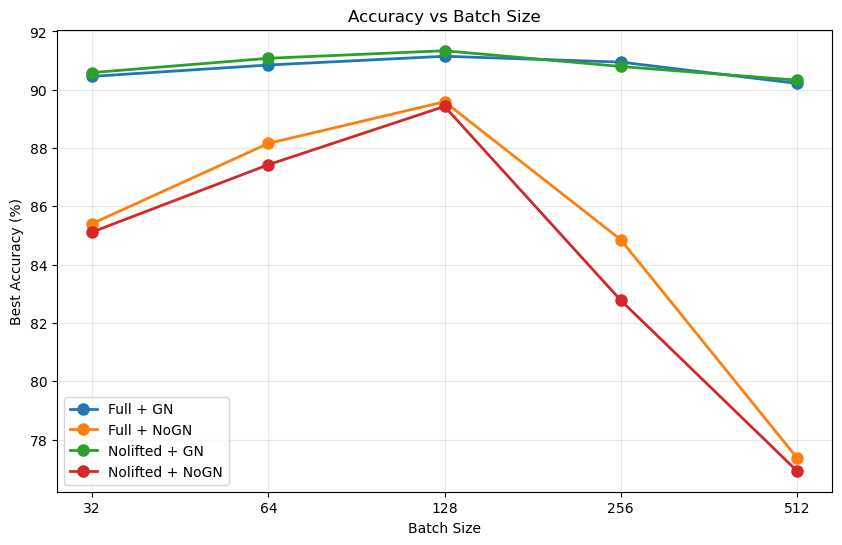


Batch Size 分析:
  Full + GN: 最佳 batch size = 128, acc = 91.15%
  Full + NoGN: 最佳 batch size = 128, acc = 89.59%
  Nolifted + GN: 最佳 batch size = 128, acc = 91.34%
  Nolifted + NoGN: 最佳 batch size = 128, acc = 89.43%


In [21]:
# Batch Size Search
RUN_BS_SWEEP = True

if RUN_BS_SWEEP:
    bs_values = [32, 64, 128, 256, 512]
    variants = [
        ('Full + GN', {'eta': 0.7, 'use_global_norm': True}),
        ('Full + NoGN', {'eta': 0.7, 'use_global_norm': False, 'lr': 3e-3}),
        ('Nolifted + GN', {'eta': 1.0, 'use_global_norm': True}),
        ('Nolifted + NoGN', {'eta': 1.0, 'use_global_norm': False, 'lr': 3e-3}),
    ]
    
    bs_sweep_results = {}
    
    for bs in bs_values:
        # 创建对应 batch size 的 data loader
        train_loader_bs, test_loader_bs = get_cifar10_loaders(batch_size=bs)
        
        for var_name, var_override in variants:
            cfg = {**BASE_CONFIG, **var_override}
            exp_name = f"{var_name}_bs{bs}"
            
            try:
                result = run_experiment(
                    name=exp_name,
                    optimizer_kwargs=cfg,
                    train_loader=train_loader_bs,
                    test_loader=test_loader_bs,
                    device=DEVICE,
                    epochs=30,
                    save_checkpoints=False,
                    collect_diagnostics=False,
                    seed=CONFIG['seed'],
                )
                bs_sweep_results[exp_name] = {
                    'bs': bs,
                    'variant': var_name,
                    'best_acc': result['best_acc'],
                    'converged': result['best_acc'] > 50,
                }
            except Exception as e:
                print(f"  {exp_name} FAILED: {e}")
                bs_sweep_results[exp_name] = {
                    'bs': bs,
                    'variant': var_name,
                    'best_acc': 0,
                    'converged': False,
                }
    
    # 绘制 Batch Size 曲线
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for var_name, _ in variants:
        bss = []
        accs = []
        for exp_name, r in bs_sweep_results.items():
            if r['variant'] == var_name:
                bss.append(r['bs'])
                accs.append(r['best_acc'])
        sorted_pairs = sorted(zip(bss, accs))
        bss, accs = zip(*sorted_pairs)
        ax.plot(bss, accs, 'o-', label=var_name, linewidth=2, markersize=8)
    
    ax.set_xscale('log', base=2)
    ax.set_xlabel('Batch Size')
    ax.set_ylabel('Best Accuracy (%)')
    ax.set_title('Accuracy vs Batch Size')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(bs_values)
    ax.set_xticklabels(bs_values)
    
    plt.savefig(f"{CONFIG['output_dir']}/bs_sweep.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\nBatch Size 分析:")
    for var_name, _ in variants:
        best_bs = max(
            [(r['bs'], r['best_acc']) for r in bs_sweep_results.values() if r['variant'] == var_name],
            key=lambda x: x[1],
            default=(0, 0)
        )
        print(f"  {var_name}: 最佳 batch size = {best_bs[0]}, acc = {best_bs[1]:.2f}%")

In [22]:
# LR × Batch Size 2D Grid Search
RUN_GRID_SEARCH = True

if RUN_GRID_SEARCH:
    lr_values_grid = [3e-5, 1e-4, 3e-4, 1e-3, 3e-3]
    bs_values_grid = [32, 64, 128, 256, 512]
    
    variants_grid = [
        ('Full + GN', {'eta': 0.7, 'use_global_norm': True}),
        ('Full + NoGN', {'eta': 0.7, 'use_global_norm': False}),
        ('Nolifted + GN', {'eta': 1.0, 'use_global_norm': True}),
        ('Nolifted + NoGN', {'eta': 1.0, 'use_global_norm': False}),
    ]
    
    grid_results = {var_name: {} for var_name, _ in variants_grid}
    
    for bs in bs_values_grid:
        train_loader_grid, test_loader_grid = get_cifar10_loaders(batch_size=bs)
        
        for lr in lr_values_grid:
            for var_name, var_override in variants_grid:
                cfg = {**BASE_CONFIG, **var_override, 'lr': lr}
                exp_name = f"{var_name}_lr{lr}_bs{bs}"
                
                try:
                    result = run_experiment(
                        name=exp_name,
                        optimizer_kwargs=cfg,
                        train_loader=train_loader_grid,
                        test_loader=test_loader_grid,
                        device=DEVICE,
                        epochs=30,
                        save_checkpoints=False,
                        collect_diagnostics=False,
                        seed=CONFIG['seed'],
                    )
                    grid_results[var_name][(lr, bs)] = result['best_acc']
                except Exception as e:
                    print(f"  {exp_name} FAILED: {e}")
                    grid_results[var_name][(lr, bs)] = 0.0
    
    # 保存 grid results
    with open(f"{CONFIG['output_dir']}/grid_search_results.json", 'w') as f:
        # 转换 key 为 string 以便 JSON 序列化
        json_results = {
            var_name: {f"lr{k[0]}_bs{k[1]}": v for k, v in var_dict.items()}
            for var_name, var_dict in grid_results.items()
        }
        json.dump(json_results, f, indent=2)
    
    print("\nGrid search 完成，结果已保存")

Train: 50000 samples, 1563 batches
Test: 10000 samples

Experiment: Full + GN_lr3e-05_bs32
Config: {'lr': 3e-05, 'weight_decay': 0.1, 'beta1': 0.9, 'beta2': 0.99, 'gamma': 5.0, 'lambda_b': 0.2, 'eta': 0.7, 'use_global_norm': True, 'normalize_belief_properly': False, 'use_sign': False}


Full + GN_lr3e-05_bs32:   0%|          | 0/30 [00:00<?, ?it/s]


✓ Full + GN_lr3e-05_bs32: Best=91.59%, Final=91.39%
  Stability: spike_count=5259, loss_std=0.3033

Experiment: Full + NoGN_lr3e-05_bs32
Config: {'lr': 3e-05, 'weight_decay': 0.1, 'beta1': 0.9, 'beta2': 0.99, 'gamma': 5.0, 'lambda_b': 0.2, 'eta': 0.7, 'use_global_norm': False, 'normalize_belief_properly': False, 'use_sign': False}


Full + NoGN_lr3e-05_bs32:   0%|          | 0/30 [00:00<?, ?it/s]


✓ Full + NoGN_lr3e-05_bs32: Best=49.02%, Final=49.02%
  Stability: spike_count=0, loss_std=0.2509

Experiment: Nolifted + GN_lr3e-05_bs32
Config: {'lr': 3e-05, 'weight_decay': 0.1, 'beta1': 0.9, 'beta2': 0.99, 'gamma': 5.0, 'lambda_b': 0.2, 'eta': 1.0, 'use_global_norm': True, 'normalize_belief_properly': False, 'use_sign': False}


...


✓ Full + NoGN_lr0.003_bs512: Best=77.21%, Final=76.95%
  Stability: spike_count=0, loss_std=0.4309

Experiment: Nolifted + GN_lr0.003_bs512
Config: {'lr': 0.003, 'weight_decay': 0.1, 'beta1': 0.9, 'beta2': 0.99, 'gamma': 5.0, 'lambda_b': 0.2, 'eta': 1.0, 'use_global_norm': True, 'normalize_belief_properly': False, 'use_sign': False}


Nolifted + GN_lr0.003_bs512:   0%|          | 0/30 [00:00<?, ?it/s]


✓ Nolifted + GN_lr0.003_bs512: Best=11.58%, Final=9.99%
  Stability: spike_count=3, loss_std=0.9907

Experiment: Nolifted + NoGN_lr0.003_bs512
Config: {'lr': 0.003, 'weight_decay': 0.1, 'beta1': 0.9, 'beta2': 0.99, 'gamma': 5.0, 'lambda_b': 0.2, 'eta': 1.0, 'use_global_norm': False, 'normalize_belief_properly': False, 'use_sign': False}


Nolifted + NoGN_lr0.003_bs512:   0%|          | 0/30 [00:00<?, ?it/s]


✓ Nolifted + NoGN_lr0.003_bs512: Best=77.29%, Final=77.29%
  Stability: spike_count=0, loss_std=0.4287

Grid search 完成，结果已保存


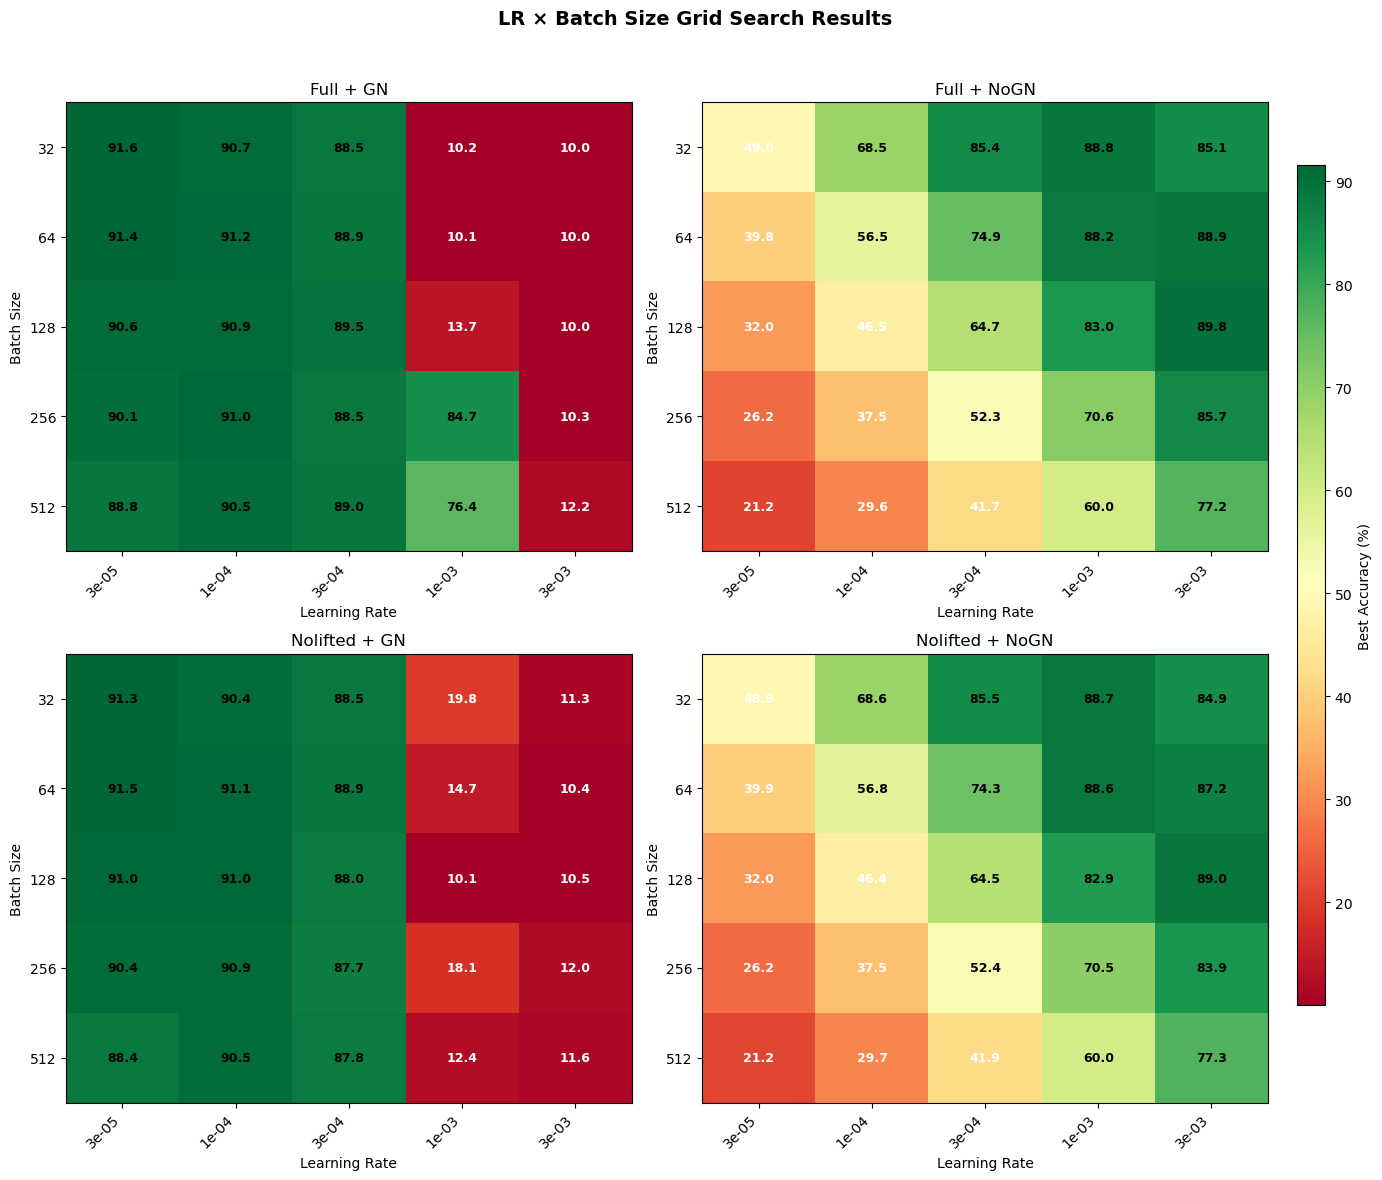

In [28]:
def plot_grid_heatmap(grid_results, lr_values, bs_values, output_dir):
    """绘制每个 variant 的 LR×BS heatmap"""
    n_variants = len(grid_results)
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()
    
    # 计算全局 vmin, vmax 以保持颜色一致
    all_accs = []
    for var_dict in grid_results.values():
        all_accs.extend(var_dict.values())
    vmin = min(all_accs) if all_accs else 0
    vmax = max(all_accs) if all_accs else 100
    
    for idx, (var_name, var_dict) in enumerate(grid_results.items()):
        ax = axes[idx]
        
        # 构建 2D 矩阵
        acc_matrix = np.zeros((len(bs_values), len(lr_values)))
        for i, bs in enumerate(bs_values):
            for j, lr in enumerate(lr_values):
                acc_matrix[i, j] = var_dict.get((lr, bs), 0)
        
        # 绘制 heatmap
        im = ax.imshow(acc_matrix, cmap='RdYlGn', aspect='auto', vmin=vmin, vmax=vmax)
        
        # 设置刻度
        ax.set_xticks(range(len(lr_values)))
        ax.set_xticklabels([f'{lr:.0e}' for lr in lr_values], rotation=45, ha='right')
        ax.set_yticks(range(len(bs_values)))
        ax.set_yticklabels(bs_values)
        ax.set_xlabel('Learning Rate')
        ax.set_ylabel('Batch Size')
        ax.set_title(var_name)
        
        # 添加数值标注
        for i in range(len(bs_values)):
            for j in range(len(lr_values)):
                val = acc_matrix[i, j]
                color = 'white' if val < (vmin + vmax) / 2 else 'black'
                ax.text(j, i, f'{val:.1f}', ha='center', va='center',
                       color=color, fontsize=9, fontweight='bold')
    
    fig.suptitle('LR × Batch Size Grid Search Results', fontsize=14, fontweight='bold')
    
    # 先调整布局，给右侧留出空间
    plt.tight_layout(rect=[0, 0, 0.92, 0.96])
    
    # 手动在最右侧添加 colorbar
    cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
    fig.colorbar(im, cax=cbar_ax, label='Best Accuracy (%)')
    
    plt.savefig(f"{output_dir}/lr_bs_grid_heatmap.png", dpi=150, bbox_inches='tight')
    plt.show()
    return fig

# 绘制 heatmap
if RUN_GRID_SEARCH:
    plot_grid_heatmap(grid_results, lr_values_grid, bs_values_grid, CONFIG['output_dir'])

In [27]:
# 打印最优超参数汇总
if RUN_GRID_SEARCH:
    print("\n" + "="*60)
    print("最优超参数汇总")
    print("="*60)
    
    summary_data = []
    for var_name, var_dict in grid_results.items():
        if var_dict:
            best_key = max(var_dict.keys(), key=lambda k: var_dict[k])
            best_acc = var_dict[best_key]
            summary_data.append({
                'Variant': var_name,
                'Best LR': best_key[0],
                'Best BS': best_key[1],
                'Best Acc (%)': f'{best_acc:.2f}'
            })
            print(f"\n{var_name}:")
            print(f"  最优 LR = {best_key[0]:.0e}, BS = {best_key[1]}")
            print(f"  Best Accuracy = {best_acc:.2f}%")
    
    # 创建 DataFrame 汇总表
    summary_df = pd.DataFrame(summary_data)
    print("\n汇总表:")
    print(summary_df.to_string(index=False))
    
    # 保存汇总表
    summary_df.to_csv(f"{CONFIG['output_dir']}/grid_search_summary.csv", index=False)


最优超参数汇总

Full + GN:
  最优 LR = 3e-05, BS = 32
  Best Accuracy = 91.59%

Full + NoGN:
  最优 LR = 3e-03, BS = 128
  Best Accuracy = 89.76%

Nolifted + GN:
  最优 LR = 3e-05, BS = 64
  Best Accuracy = 91.51%

Nolifted + NoGN:
  最优 LR = 3e-03, BS = 128
  Best Accuracy = 89.02%

汇总表:
        Variant  Best LR  Best BS Best Acc (%)
      Full + GN  0.00003       32        91.59
    Full + NoGN  0.00300      128        89.76
  Nolifted + GN  0.00003       64        91.51
Nolifted + NoGN  0.00300      128        89.02
